In [44]:
from google.colab import drive
print("Attempting to mount Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    print("Google Drive mounted successfully.")
except Exception as e:
    print(f"Google Drive mount failed: {e}")
    print("Please ensure you've authorized Google Drive access in the popup window.")

Attempting to mount Google Drive...
Mounted at /content/drive
Google Drive mounted successfully.


## Clone the dataset

The dataset used in this notebook is the IEEE PHM 2012 Data Challenge dataset.


In [45]:
# Navigate to your Google Drive
%cd /content/drive/MyDrive/

# Clone the dataset directly into a folder in your Google Drive
!git clone https://github.com/Lucky-Loek/ieee-phm-2012-data-challenge-dataset.git
%cd /content

/content/drive/MyDrive
fatal: destination path 'ieee-phm-2012-data-challenge-dataset' already exists and is not an empty directory.
/content


In [46]:
import os
import glob
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from scipy.fft import fft, fftfreq
import pywt

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 50)
print("Libraries imported.")


Libraries imported.


In [47]:
import glob
import time
from scipy import stats
from scipy.fft import fft, fftfreq
import pywt

In [48]:
RUNNING_IN_COLAB = True  # set False if running outside Colab

if RUNNING_IN_COLAB:
    # Corrected ROOT_DIR based on where the git clone actually placed the data
    ROOT_DIR = '/content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset'  # Corrected path
else:
    ROOT_DIR = '/home/claude/femto'  # local path used during development/testing

LEARNING_SET   = os.path.join(ROOT_DIR, 'Learning_set')
FULL_TEST_SET  = os.path.join(ROOT_DIR, 'Full_Test_Set')
TEST_SET       = os.path.join(ROOT_DIR, 'Test_set')

FS_ACC = 25600                 # Hz, confirmed in Chapter 3b
SAMPLES_PER_ACC_FILE = 2560    # confirmed: 0.1s window @ 25.6kHz

for p, name in [(LEARNING_SET, 'Learning_set'), (FULL_TEST_SET, 'Full_Test_Set'), (TEST_SET, 'Test_set')]:
    status = "OK" if os.path.isdir(p) else "NOT FOUND"
    print(f"{name:15s} -> {p}  [{status}]")

Learning_set    -> /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set  [OK]
Full_Test_Set   -> /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Full_Test_Set  [OK]
Test_set        -> /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Test_set  [OK]


In [49]:
print(f"\n--- Diagnosing {LEARNING_SET} ---\n")

if not os.path.isdir(LEARNING_SET):
    print(f"Error: {LEARNING_SET} does not exist. Please check ROOT_DIR and your Google Drive contents.")
else:
    print(f"Contents of {LEARNING_SET} (first 10 items):")
    learning_set_contents = os.listdir(LEARNING_SET)
    if learning_set_contents:
        for item in sorted(learning_set_contents)[:10]:
            item_path = os.path.join(LEARNING_SET, item)
            status = "(DIR)" if os.path.isdir(item_path) else "(FILE)"
            print(f"  - {item} {status}")
    else:
        print("  (Empty directory)")

_sample_bearing_path = os.path.join(LEARNING_SET, "Bearing1_1")
print(f"\nContents of {_sample_bearing_path} (first 10 items):\n")
if not os.path.isdir(_sample_bearing_path):
    print(f"Error: {_sample_bearing_path} does not exist. This is likely the cause of the IndexError.")
    print("Please ensure 'Bearing1_1' is a directory inside 'Learning_set'.")
else:
    sample_bearing_contents = os.listdir(_sample_bearing_path)
    if sample_bearing_contents:
        for item in sorted(sample_bearing_contents)[:10]:
            item_path = os.path.join(_sample_bearing_path, item)
            status = "(DIR)" if os.path.isdir(item_path) else "(FILE)"
            print(f"  - {item} {status}")
        print(f"Total items in {_sample_bearing_path}: {len(sample_bearing_contents)}")
    else:
        print("  (Empty directory or no matching files)")

print("\n--- End Diagnosis ---")


--- Diagnosing /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set ---

Contents of /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set (first 10 items):
  - Bearing1_1 (DIR)
  - Bearing1_2 (DIR)
  - Bearing2_1 (DIR)
  - Bearing2_2 (DIR)
  - Bearing3_1 (DIR)
  - Bearing3_2 (DIR)

Contents of /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set/Bearing1_1 (first 10 items):

  - acc_00001.csv (FILE)
  - acc_00002.csv (FILE)
  - acc_00003.csv (FILE)
  - acc_00004.csv (FILE)
  - acc_00005.csv (FILE)
  - acc_00006.csv (FILE)
  - acc_00007.csv (FILE)
  - acc_00008.csv (FILE)
  - acc_00009.csv (FILE)
  - acc_00010.csv (FILE)
Total items in /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set/Bearing1_1: 3269

--- End Diagnosis ---


In [50]:
# Helper cell to inspect Google Drive contents and find the dataset path.
# If you run into 'Mountpoint must not already contain files' frequently, consider
# restarting the Colab runtime and executing cells from the beginning after a clean mount.

import os

DRIVE_BASE = '/content/drive/MyDrive'

print("Listing contents of /content/drive/MyDrive (first 50 items):")
if os.path.exists(DRIVE_BASE) and os.path.isdir(DRIVE_BASE):
    for item in sorted(os.listdir(DRIVE_BASE))[:50]:
        full_path = os.path.join(DRIVE_BASE, item)
        is_dir_str = " (DIR)" if os.path.isdir(full_path) else ""
        print(f" - {item}{is_dir_str}")
else:
    print(f"Error: {DRIVE_BASE} does not exist or is not a directory.")
    print("Please ensure Google Drive is mounted correctly before running this cell.")

print("\nSearching for 'ieee-phm-2012-data-challenge-dataset' recursively under MyDrive...")
found_dataset_root = None
search_limit_depth = 3 # Limit search depth to avoid excessively long execution

for root, dirs, files in os.walk(DRIVE_BASE):
    if 'ieee-phm-2012-data-challenge-dataset' in dirs:
        found_dataset_root = os.path.join(root, 'ieee-phm-2012-data-challenge-dataset')
        print(f"  FOUND dataset root directory at: {found_dataset_root}")
        break # Stop at the first discovery
    elif 'ieee-phm-2012-data-challenge-dataset.git' in dirs: # Also check for .git suffix
        found_dataset_root = os.path.join(root, 'ieee-phm-2012-data-challenge-dataset.git')
        print(f"  FOUND dataset root directory (with .git suffix) at: {found_dataset_root}")
        break # Stop at the first discovery

    # Limit search depth
    if root.count(os.sep) - DRIVE_BASE.count(os.sep) > search_limit_depth:
        del dirs[:]

if not found_dataset_root:
    print("  Dataset root directory not found. Please ensure it's present in your Google Drive.")
    print("  If it's there, you might need to manually specify the path or check for typos.")
else:
    print("\nSuggested ROOT_DIR value based on search results:")
    print(f"  ROOT_DIR = '{found_dataset_root}'")

    # Further check for 'Learning_set' inside the found root
    learning_set_path = os.path.join(found_dataset_root, 'Learning_set')
    if os.path.isdir(learning_set_path):
        print(f"  'Learning_set' subdirectory found at: {learning_set_path} [OK]")
    else:
        print(f"  Warning: 'Learning_set' subdirectory NOT FOUND at: {learning_set_path}")
        print("  This might mean the dataset was not fully cloned or extracted.")


Listing contents of /content/drive/MyDrive (first 50 items):
 - Colab Notebooks (DIR)
 - FEMTO-ST (DIR)
 - ieee-phm-2012-data-challenge-dataset (DIR)

Searching for 'ieee-phm-2012-data-challenge-dataset' recursively under MyDrive...
  FOUND dataset root directory at: /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset

Suggested ROOT_DIR value based on search results:
  ROOT_DIR = '/content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset'
  'Learning_set' subdirectory found at: /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set [OK]


In [51]:
def list_bearings(set_path):
    """Return sorted bearing folder names within a dataset split."""
    return sorted([d for d in os.listdir(set_path) if os.path.isdir(os.path.join(set_path, d))])


def list_acc_files(bearing_path):
    return sorted(glob.glob(os.path.join(bearing_path, "acc_*.csv")))


def list_temp_files(bearing_path):
    return sorted(glob.glob(os.path.join(bearing_path, "temp_*.csv")))


def _detect_delimiter(filepath):
    """PRIMARY-SOURCE FINDING (verified during notebook testing, not documented in the
    surveyed literature): a subset of acc_*.csv and temp_*.csv files in this dataset use
    semicolon delimiters instead of commas -- confirmed on Full_Test_Set/Bearing1_4 (all
    1428 acc files) and on temperature files across 19 different bearings spanning all
    three splits. Delimiter must be detected per-file, not assumed dataset-wide."""
    with open(filepath, "r") as f:
        first_line = f.readline()
    return ";" if ";" in first_line else ","


def read_acc_file(filepath):
    delim = _detect_delimiter(filepath)
    return pd.read_csv(filepath, header=None, sep=delim,
                        names=["hour", "min", "sec", "usec", "horiz", "vert"])


def read_temp_file(filepath):
    delim = _detect_delimiter(filepath)
    return pd.read_csv(filepath, header=None, sep=delim,
                        names=["hour", "min", "sec", "idx", "temperature"])


# Quick sanity check on one bearing
_sample_path = os.path.join(LEARNING_SET, "Bearing1_1")
_acc_files = list_acc_files(_sample_path)
_temp_files = list_temp_files(_sample_path)
print(f"Bearing1_1: {len(_acc_files)} accelerometer files, {len(_temp_files)} temperature files")
read_acc_file(_acc_files[0]).head()


Bearing1_1: 2803 accelerometer files, 466 temperature files


,hour,min,sec,usec,horiz,vert
0,9,39,39,65664.0,0.552,-0.146
1,9,39,39,65703.0,0.501,-0.480
2,9,39,39,65742.0,0.138,0.435
3,9,39,39,65781.0,-0.423,0.240
4,9,39,39,65820.0,-0.802,0.020


In [52]:
import glob # Ensure glob is imported in this context
import os

_test_bearing_path = os.path.join(LEARNING_SET, "Bearing1_1")
print(f"Testing glob.glob for: {os.path.join(_test_bearing_path, "acc_*.csv")}")
_found_files_glob = glob.glob(os.path.join(_test_bearing_path, "acc_*.csv"))
print(f"Number of files found by glob.glob: {len(_found_files_glob)}")
if _found_files_glob:
    print(f"First 5 files found by glob.glob: {_found_files_glob[:5]}")
else:
    print("glob.glob returned an empty list. This is unexpected given os.listdir output.")

# Also test os.listdir to re-confirm
print(f"Testing os.listdir for: {_test_bearing_path}")
_found_files_listdir = [f for f in os.listdir(_test_bearing_path) if f.startswith("acc_") and f.endswith(".csv")]
print(f"Number of files found by os.listdir (filtered): {len(_found_files_listdir)}")
if _found_files_listdir:
    print(f"First 5 files found by os.listdir (filtered): {sorted(_found_files_listdir)[:5]}")

Testing glob.glob for: /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set/Bearing1_1/acc_*.csv
Number of files found by glob.glob: 2803
First 5 files found by glob.glob: ['/content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set/Bearing1_1/acc_02270.csv', '/content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set/Bearing1_1/acc_02271.csv', '/content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set/Bearing1_1/acc_02272.csv', '/content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set/Bearing1_1/acc_02273.csv', '/content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set/Bearing1_1/acc_02274.csv']
Testing os.listdir for: /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set/Bearing1_1
Number of files found by os.listdir (filtered): 2803
First 5 files found by os.listdir (filtered): ['acc_00001.csv', 'acc_00002.csv', 'acc_00003.csv', 'acc_00004.csv', 'acc_00005.csv']


In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
# Navigate to your Google Drive
%cd /content/drive/MyDrive/

# Clone the dataset directly into a folder in your Google Drive
!git clone https://github.com/Lucky-Loek/ieee-phm-2012-data-challenge-dataset.git

/content/drive/MyDrive
fatal: destination path 'ieee-phm-2012-data-challenge-dataset' already exists and is not an empty directory.


In [55]:
def bearing_condition(bearing_name):
    return bearing_name.split("_")[0].replace("Bearing", "Condition ")


def estimate_duration_hours(acc_files):
    if len(acc_files) == 0:
        return None
    first = pd.read_csv(acc_files[0], header=None, nrows=1, sep=_detect_delimiter(acc_files[0]))
    last = pd.read_csv(acc_files[-1], header=None, nrows=1, sep=_detect_delimiter(acc_files[-1]))
    h1, m1, s1 = first.iloc[0, 0], first.iloc[0, 1], first.iloc[0, 2]
    h2, m2, s2 = last.iloc[0, 0], last.iloc[0, 1], last.iloc[0, 2]
    t1, t2 = h1 * 3600 + m1 * 60 + s1, h2 * 3600 + m2 * 60 + s2
    dur = (t2 - t1) if t2 >= t1 else (t2 - t1 + 24 * 3600)
    return round(dur / 3600, 2)


def build_dataset_summary():
    rows = []
    for set_name, set_path in [("Learning_set", LEARNING_SET),
                                ("Full_Test_Set", FULL_TEST_SET),
                                ("Test_set", TEST_SET)]:
        if not os.path.isdir(set_path):
            continue
        for bearing in list_bearings(set_path):
            bpath = os.path.join(set_path, bearing)
            acc_files = list_acc_files(bpath)
            temp_files = list_temp_files(bpath)
            rows.append({
                "set": set_name,
                "bearing": bearing,
                "condition": bearing_condition(bearing),
                "n_acc_files": len(acc_files),
                "n_temp_files": len(temp_files),
                "has_temperature": len(temp_files) > 0,
                "duration_hours": estimate_duration_hours(acc_files),
            })
    return pd.DataFrame(rows)


dataset_summary = build_dataset_summary()
dataset_summary


,set,bearing,condition,n_acc_files,n_temp_files,has_temperature,duration_hours
0,Learning_set,Bearing1_1,Condition 1,2803,466,True,7.78
1,Learning_set,Bearing1_2,Condition 1,871,144,True,2.42
2,Learning_set,Bearing2_1,Condition 2,911,151,True,2.53
3,Learning_set,Bearing2_2,Condition 2,797,0,False,2.21
4,Learning_set,Bearing3_1,Condition 3,515,89,True,1.43
5,Learning_set,Bearing3_2,Condition 3,1637,0,False,4.54
6,Full_Test_Set,Bearing1_3,Condition 1,2375,0,False,6.59
7,Full_Test_Set,Bearing1_4,Condition 1,1428,237,True,3.96
8,Full_Test_Set,Bearing1_5,Condition 1,2463,410,True,6.84
9,Full_Test_Set,Bearing1_6,Condition 1,2448,408,True,6.80


In [56]:
print("Total run-to-failure experiments (Learning_set + Full_Test_Set):",
      len(dataset_summary[dataset_summary.set.isin(['Learning_set','Full_Test_Set'])]))
print()
print("Bearings with NO temperature data (confirmed limitation from Chapter 3b):")
dataset_summary[~dataset_summary.has_temperature][["set", "bearing"]]


Total run-to-failure experiments (Learning_set + Full_Test_Set): 17

Bearings with NO temperature data (confirmed limitation from Chapter 3b):


,set,bearing
3,Learning_set,Bearing2_2
5,Learning_set,Bearing3_2
6,Full_Test_Set,Bearing1_3
11,Full_Test_Set,Bearing2_3
17,Test_set,Bearing1_3
22,Test_set,Bearing2_3
25,Test_set,Bearing2_6


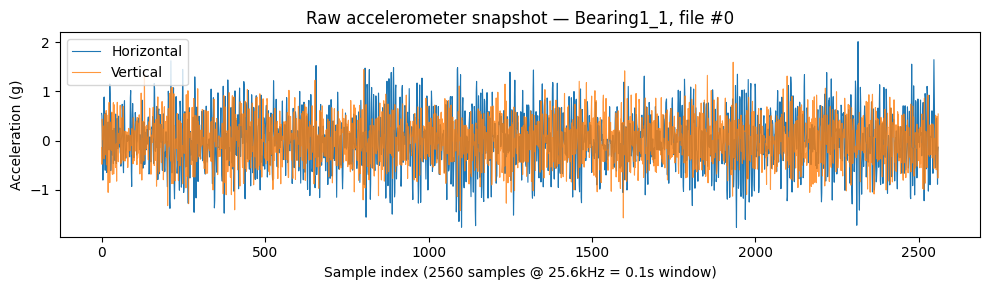

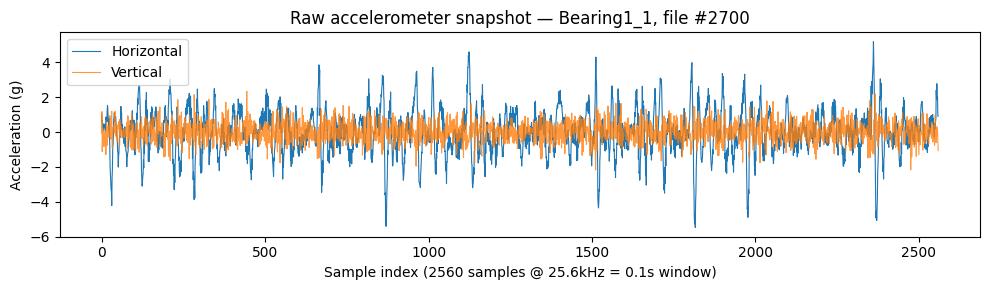

In [57]:
def plot_raw_snapshot(bearing_path, file_index=0):
    files = list_acc_files(bearing_path)
    df = read_acc_file(files[file_index])
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(df["horiz"].values, label="Horizontal", linewidth=0.8)
    ax.plot(df["vert"].values, label="Vertical", linewidth=0.8, alpha=0.8)
    ax.set_title(f"Raw accelerometer snapshot — {os.path.basename(bearing_path)}, file #{file_index}")
    ax.set_xlabel("Sample index (2560 samples @ 25.6kHz = 0.1s window)")
    ax.set_ylabel("Acceleration (g)")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_raw_snapshot(os.path.join(LEARNING_SET, "Bearing1_1"), file_index=0)
plot_raw_snapshot(os.path.join(LEARNING_SET, "Bearing1_1"), file_index=2700)  # near end-of-life


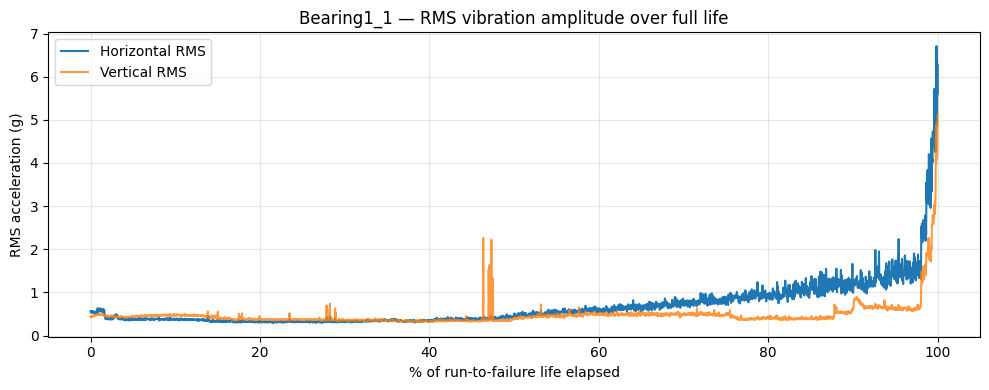

RMS escalation factor (end/start): 10.0x — consistent with Chapter 3b's verified ~12x finding on this same bearing.


In [58]:
def rms_life_trend(bearing_path):
    files = list_acc_files(bearing_path)
    rms_h, rms_v = [], []
    for f in files:
        df = read_acc_file(f)
        rms_h.append(np.sqrt(np.mean(df["horiz"].values ** 2)))
        rms_v.append(np.sqrt(np.mean(df["vert"].values ** 2)))
    return np.array(rms_h), np.array(rms_v)

_rms_h, _rms_v = rms_life_trend(os.path.join(LEARNING_SET, "Bearing1_1"))
life_pct = np.linspace(0, 100, len(_rms_h))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(life_pct, _rms_h, label="Horizontal RMS")
ax.plot(life_pct, _rms_v, label="Vertical RMS", alpha=0.8)
ax.set_title("Bearing1_1 — RMS vibration amplitude over full life")
ax.set_xlabel("% of run-to-failure life elapsed")
ax.set_ylabel("RMS acceleration (g)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"RMS escalation factor (end/start): {_rms_h[-1]/_rms_h[0]:.1f}x — "
      f"consistent with Chapter 3b's verified ~12x finding on this same bearing.")


In [59]:
def build_snapshot_index(set_name, set_path, full_test_lookup=None):
    """Build one row per accelerometer snapshot file, with RUL label and metadata.

    full_test_lookup: dict {bearing_name: total_snapshot_count} used only when
    set_name == 'Test_set', to compute RUL against the true (Full_Test_Set) life length.
    """
    rows = []
    for bearing in list_bearings(set_path):
        bpath = os.path.join(set_path, bearing)
        acc_files = list_acc_files(bpath)
        temp_files = set(os.path.basename(f).replace("temp_", "").replace(".csv", "")
                          for f in list_temp_files(bpath))

        if set_name == "Test_set" and full_test_lookup is not None and bearing in full_test_lookup:
            total_life = full_test_lookup[bearing]
        else:
            total_life = len(acc_files)  # Learning_set / Full_Test_Set: true full life

        for i, f in enumerate(acc_files):
            idx_str = os.path.basename(f).replace("acc_", "").replace(".csv", "")
            rows.append({
                "set": set_name,
                "bearing": bearing,
                "condition": bearing_condition(bearing),
                "snapshot_idx": i + 1,
                "acc_filepath": f,
                "has_temperature": idx_str in temp_files,
                "total_life_snapshots": total_life,
                "RUL_snapshots": total_life - (i + 1),
            })
    return pd.DataFrame(rows)


# Build lookup of true full-life snapshot counts from Full_Test_Set, for Test_set RUL labeling
_full_test_lookup = {
    b: len(list_acc_files(os.path.join(FULL_TEST_SET, b)))
    for b in list_bearings(FULL_TEST_SET)
}

learning_index  = build_snapshot_index("Learning_set", LEARNING_SET)
fulltest_index  = build_snapshot_index("Full_Test_Set", FULL_TEST_SET)
test_index      = build_snapshot_index("Test_set", TEST_SET, full_test_lookup=_full_test_lookup)

print("Learning_set snapshots :", len(learning_index))
print("Full_Test_Set snapshots:", len(fulltest_index))
print("Test_set snapshots     :", len(test_index))
learning_index.head()


Learning_set snapshots : 7534
Full_Test_Set snapshots: 17355
Test_set snapshots     : 13959


,set,bearing,condition,snapshot_idx,acc_filepath,has_temperature,total_life_snapshots,RUL_snapshots
0,Learning_set,Bearing1_1,Condition 1,1,/content/drive/MyDrive/ieee-phm-2012-data-chal...,True,2803,2802
1,Learning_set,Bearing1_1,Condition 1,2,/content/drive/MyDrive/ieee-phm-2012-data-chal...,True,2803,2801
2,Learning_set,Bearing1_1,Condition 1,3,/content/drive/MyDrive/ieee-phm-2012-data-chal...,True,2803,2800
3,Learning_set,Bearing1_1,Condition 1,4,/content/drive/MyDrive/ieee-phm-2012-data-chal...,True,2803,2799
4,Learning_set,Bearing1_1,Condition 1,5,/content/drive/MyDrive/ieee-phm-2012-data-chal...,True,2803,2798


In [60]:
def time_domain_features(sig, prefix=""):
    feats = {}
    rms = np.sqrt(np.mean(sig ** 2))
    peak = np.max(np.abs(sig))
    mean_abs = np.mean(np.abs(sig))

    feats[f"{prefix}mean"] = np.mean(sig)
    feats[f"{prefix}std"] = np.std(sig)
    feats[f"{prefix}rms"] = rms
    feats[f"{prefix}variance"] = np.var(sig)
    feats[f"{prefix}skewness"] = stats.skew(sig)
    feats[f"{prefix}kurtosis"] = stats.kurtosis(sig)
    feats[f"{prefix}peak"] = peak
    feats[f"{prefix}peak_to_peak"] = np.max(sig) - np.min(sig)
    feats[f"{prefix}crest_factor"] = peak / (rms + 1e-12)
    feats[f"{prefix}shape_factor"] = rms / (mean_abs + 1e-12)
    feats[f"{prefix}impulse_factor"] = peak / (mean_abs + 1e-12)
    feats[f"{prefix}clearance_factor"] = peak / (np.mean(np.sqrt(np.abs(sig))) ** 2 + 1e-12)
    return feats


# Sanity check on one file
_df = read_acc_file(list_acc_files(os.path.join(LEARNING_SET, "Bearing1_1"))[0])
time_domain_features(_df["horiz"].values, prefix="horiz_")


{'horiz_mean': np.float64(0.0034652343749999996),
 'horiz_std': np.float64(0.5617349696566),
 'horiz_rms': np.float64(0.56174565773522),
 'horiz_variance': np.float64(0.31554617613510133),
 'horiz_skewness': np.float64(-0.00471106707861808),
 'horiz_kurtosis': np.float64(-0.13146502800822502),
 'horiz_peak': np.float64(2.01),
 'horiz_peak_to_peak': np.float64(3.7729999999999997),
 'horiz_crest_factor': np.float64(3.578131797404724),
 'horiz_shape_factor': np.float64(1.2459043366301492),
 'horiz_impulse_factor': np.float64(4.458009923428713),
 'horiz_clearance_factor': np.float64(5.246059685915493)}

In [61]:
def freq_domain_features(sig, fs=FS_ACC, prefix=""):
    n = len(sig)
    freqs = fftfreq(n, 1 / fs)[: n // 2]
    mags = np.abs(fft(sig))[: n // 2]
    mags_norm = mags / (np.sum(mags) + 1e-12)

    feats = {}
    mean_freq = np.sum(freqs * mags_norm)
    feats[f"{prefix}spectral_mean_freq"] = mean_freq
    feats[f"{prefix}spectral_rms_freq"] = np.sqrt(np.sum((freqs ** 2) * mags_norm))
    feats[f"{prefix}spectral_std_freq"] = np.sqrt(np.sum(((freqs - mean_freq) ** 2) * mags_norm))
    feats[f"{prefix}spectral_energy"] = np.sum(mags ** 2)
    feats[f"{prefix}spectral_entropy"] = -np.sum(mags_norm * np.log(mags_norm + 1e-12))

    n_bands = 5
    band_edges = np.linspace(0, fs / 2, n_bands + 1)
    for i in range(n_bands):
        mask = (freqs >= band_edges[i]) & (freqs < band_edges[i + 1])
        feats[f"{prefix}band_energy_{i+1}"] = np.sum(mags[mask] ** 2)
    return feats


freq_domain_features(_df["horiz"].values, prefix="horiz_")


{'horiz_spectral_mean_freq': np.float64(4388.4393538596905),
 'horiz_spectral_rms_freq': np.float64(5143.224757259795),
 'horiz_spectral_std_freq': np.float64(2682.2305906065644),
 'horiz_spectral_energy': np.float64(1034015.95158),
 'horiz_spectral_entropy': np.float64(6.557488592846283),
 'horiz_band_energy_1': np.float64(123915.73653405049),
 'horiz_band_energy_2': np.float64(793343.8736419105),
 'horiz_band_energy_3': np.float64(98179.81787076173),
 'horiz_band_energy_4': np.float64(8380.713174503851),
 'horiz_band_energy_5': np.float64(10195.810358773371)}

In [62]:
def wavelet_features(sig, wavelet="db4", level=4, prefix=""):
    sig = np.array(sig, dtype=np.float64, copy=True)  # pywt requires a writable array
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    total_energy = sum(np.sum(c ** 2) for c in coeffs) + 1e-12

    feats = {}
    for i, c in enumerate(coeffs):
        name = "approx" if i == 0 else f"detail_{level - i + 1}"
        energy = np.sum(c ** 2)
        feats[f"{prefix}wavelet_{name}_energy_ratio"] = energy / total_energy
        feats[f"{prefix}wavelet_{name}_std"] = np.std(c)
    return feats


wavelet_features(_df["horiz"].values, prefix="horiz_")


{'horiz_wavelet_approx_energy_ratio': np.float64(0.03499871871375952),
 'horiz_wavelet_approx_std': np.float64(0.41608261028878873),
 'horiz_wavelet_detail_4_energy_ratio': np.float64(0.05044048327797591),
 'horiz_wavelet_detail_4_std': np.float64(0.4945457430465101),
 'horiz_wavelet_detail_3_energy_ratio': np.float64(0.2612318222349848),
 'horiz_wavelet_detail_3_std': np.float64(0.8111285086033811),
 'horiz_wavelet_detail_2_energy_ratio': np.float64(0.5777588064864606),
 'horiz_wavelet_detail_2_std': np.float64(0.8576760472278221),
 'horiz_wavelet_detail_1_energy_ratio': np.float64(0.0755701692868179),
 'horiz_wavelet_detail_1_std': np.float64(0.2198902048501713)}

In [63]:
FAST_DEMO = False
DEMO_SNAPSHOTS_PER_BEARING = 100  # only used if FAST_DEMO=True


def extract_features_row(acc_filepath):
    df = read_acc_file(acc_filepath)
    row = {}
    row.update(time_domain_features(df["horiz"].values, prefix="horiz_"))
    row.update(time_domain_features(df["vert"].values, prefix="vert_"))
    row.update(freq_domain_features(df["horiz"].values, prefix="horiz_"))
    row.update(freq_domain_features(df["vert"].values, prefix="vert_"))
    row.update(wavelet_features(df["horiz"].values, prefix="horiz_"))
    row.update(wavelet_features(df["vert"].values, prefix="vert_"))
    return row


def build_feature_dataset(snapshot_index_df, fast_demo=FAST_DEMO):
    all_rows = []
    bearings = snapshot_index_df["bearing"].unique()
    t_start = time.time()

    for bearing in bearings:
        b_df = snapshot_index_df[snapshot_index_df["bearing"] == bearing].reset_index(drop=True)
        if fast_demo and len(b_df) > DEMO_SNAPSHOTS_PER_BEARING:
            sample_idx = np.linspace(0, len(b_df) - 1, DEMO_SNAPSHOTS_PER_BEARING).astype(int)
            b_df = b_df.iloc[sample_idx].reset_index(drop=True)

        for _, meta_row in b_df.iterrows():
            feats = extract_features_row(meta_row["acc_filepath"])
            feats.update({
                "set": meta_row["set"],
                "bearing": meta_row["bearing"],
                "condition": meta_row["condition"],
                "snapshot_idx": meta_row["snapshot_idx"],
                "has_temperature": meta_row["has_temperature"],
                "total_life_snapshots": meta_row["total_life_snapshots"],
                "RUL_snapshots": meta_row["RUL_snapshots"],
            })
            all_rows.append(feats)

        print(f"  {bearing}: {len(b_df)} snapshots processed "
              f"({time.time()-t_start:.1f}s elapsed)")

    return pd.DataFrame(all_rows)


print("Building feature dataset for Learning_set"
      + (" (FAST_DEMO subsample)" if FAST_DEMO else " (full)") + " ...")
learning_features = build_feature_dataset(learning_index, fast_demo=FAST_DEMO)
print(f"\nDone. Shape: {learning_features.shape}")
learning_features.head()


Building feature dataset for Learning_set (full) ...
  Bearing1_1: 2803 snapshots processed (39.3s elapsed)
  Bearing1_2: 871 snapshots processed (52.3s elapsed)
  Bearing2_1: 911 snapshots processed (65.7s elapsed)
  Bearing2_2: 797 snapshots processed (78.4s elapsed)
  Bearing3_1: 515 snapshots processed (85.7s elapsed)
  Bearing3_2: 1637 snapshots processed (109.2s elapsed)

Done. Shape: (7534, 71)


,horiz_mean,horiz_std,horiz_rms,horiz_variance,horiz_skewness,horiz_kurtosis,horiz_peak,horiz_peak_to_peak,horiz_crest_factor,horiz_shape_factor,horiz_impulse_factor,horiz_clearance_factor,vert_mean,vert_std,vert_rms,vert_variance,vert_skewness,vert_kurtosis,vert_peak,vert_peak_to_peak,vert_crest_factor,vert_shape_factor,vert_impulse_factor,vert_clearance_factor,horiz_spectral_mean_freq,...,horiz_wavelet_detail_4_energy_ratio,horiz_wavelet_detail_4_std,horiz_wavelet_detail_3_energy_ratio,horiz_wavelet_detail_3_std,horiz_wavelet_detail_2_energy_ratio,horiz_wavelet_detail_2_std,horiz_wavelet_detail_1_energy_ratio,horiz_wavelet_detail_1_std,vert_wavelet_approx_energy_ratio,vert_wavelet_approx_std,vert_wavelet_detail_4_energy_ratio,vert_wavelet_detail_4_std,vert_wavelet_detail_3_energy_ratio,vert_wavelet_detail_3_std,vert_wavelet_detail_2_energy_ratio,vert_wavelet_detail_2_std,vert_wavelet_detail_1_energy_ratio,vert_wavelet_detail_1_std,set,bearing,condition,snapshot_idx,has_temperature,total_life_snapshots,RUL_snapshots
0,0.003465,0.561735,0.561746,0.315546,-0.004711,-0.131465,2.010,3.773,3.578132,1.245904,4.458010,5.246060,-0.001881,0.435797,0.435801,0.189919,0.002713,-0.035080,1.591,3.160,3.650745,1.250021,4.563510,5.375916,4388.439354,...,0.050440,0.494546,0.261232,0.811129,0.577759,0.857676,0.075570,0.219890,0.012440,0.191473,0.014524,0.205629,0.138673,0.455889,0.358513,0.521461,0.475850,0.425952,Learning_set,Bearing1_1,Condition 1,1,True,2803,2802
1,0.005609,0.535083,0.535112,0.286314,-0.025791,-0.084646,1.915,3.640,3.578687,1.247889,4.465805,5.259123,-0.000930,0.420967,0.420968,0.177214,0.077380,0.150620,1.666,3.175,3.957542,1.259639,4.985074,5.890806,4263.874462,...,0.063055,0.529155,0.234116,0.726858,0.593758,0.824360,0.067521,0.197012,0.013277,0.190875,0.018307,0.223973,0.165890,0.479763,0.345615,0.494149,0.456911,0.402850,Learning_set,Bearing1_1,Condition 1,2,True,2803,2801
2,0.004196,0.531142,0.531158,0.282111,-0.005016,0.033388,1.901,3.677,3.578971,1.259633,4.508190,5.341439,-0.002229,0.425600,0.425605,0.181135,-0.024393,-0.061552,1.584,2.937,3.721758,1.255477,4.672583,5.544456,4380.934937,...,0.068387,0.547938,0.241369,0.734770,0.581253,0.810533,0.075856,0.207592,0.023217,0.252869,0.014106,0.199511,0.129625,0.431971,0.342407,0.499250,0.490646,0.424074,Learning_set,Bearing1_1,Condition 1,3,True,2803,2800
3,-0.001824,0.554830,0.554833,0.307837,-0.080165,0.043419,1.910,3.788,3.442476,1.263041,4.347988,5.161220,-0.000594,0.445524,0.445524,0.198491,-0.008190,-0.113319,1.600,2.948,3.591275,1.247384,4.479700,5.289920,4370.240876,...,0.055308,0.512739,0.262212,0.799076,0.570481,0.838180,0.077289,0.218773,0.011962,0.191633,0.017721,0.233251,0.142377,0.471970,0.353608,0.529002,0.474331,0.434387,Learning_set,Bearing1_1,Condition 1,4,True,2803,2799
4,-0.002582,0.566646,0.566652,0.321088,-0.034187,-0.185477,1.767,3.427,3.118317,1.248193,3.892261,4.587845,0.009918,0.423731,0.423847,0.179548,0.081213,-0.034816,1.373,2.717,3.239377,1.249573,4.047839,4.773290,4380.908375,...,0.039286,0.444362,0.231528,0.771523,0.603844,0.886017,0.075531,0.222076,0.014500,0.195314,0.014824,0.203460,0.111096,0.397498,0.374302,0.518277,0.485278,0.418767,Learning_set,Bearing1_1,Condition 1,5,True,2803,2798


In [64]:
feature_cols = [c for c in learning_features.columns
                if c not in ["set", "bearing", "condition", "snapshot_idx",
                             "has_temperature", "total_life_snapshots", "RUL_snapshots"]]

X = learning_features[feature_cols].fillna(0)
y = learning_features["RUL_snapshots"]

# --- Step 1: redundancy filter (correlation > 0.95) ---
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant = [col for col in upper.columns if any(upper[col] > 0.95)]
X_reduced = X.drop(columns=redundant)

print(f"Removed {len(redundant)} redundant features (corr > 0.95): {redundant}")
print(f"Remaining after redundancy filter: {X_reduced.shape[1]} features")


Removed 19 redundant features (corr > 0.95): ['horiz_rms', 'horiz_peak_to_peak', 'horiz_impulse_factor', 'horiz_clearance_factor', 'vert_rms', 'vert_peak_to_peak', 'vert_impulse_factor', 'vert_clearance_factor', 'horiz_spectral_rms_freq', 'horiz_spectral_energy', 'horiz_band_energy_1', 'vert_spectral_rms_freq', 'vert_spectral_energy', 'vert_band_energy_3', 'horiz_wavelet_detail_3_std', 'horiz_wavelet_detail_1_energy_ratio', 'horiz_wavelet_detail_1_std', 'vert_wavelet_detail_2_std', 'vert_wavelet_detail_1_energy_ratio']
Remaining after redundancy filter: 45 features


In [65]:
# --- Step 2: relevance ranking via mutual information with RUL ---
mi_scores = mutual_info_regression(X_reduced, y, random_state=42)
mi_ranking = pd.Series(mi_scores, index=X_reduced.columns).sort_values(ascending=False)

print("Top 15 features by mutual information with RUL:")
mi_ranking.head(15)


Top 15 features by mutual information with RUL:


,0
horiz_band_energy_5,1.100410
vert_variance,1.068274
vert_std,1.062416
vert_spectral_mean_freq,1.016635
vert_wavelet_detail_1_std,0.992917
horiz_wavelet_detail_2_energy_ratio,0.991513
horiz_spectral_std_freq,0.975183
horiz_spectral_mean_freq,0.953084
vert_band_energy_5,0.951773
horiz_band_energy_4,0.872334


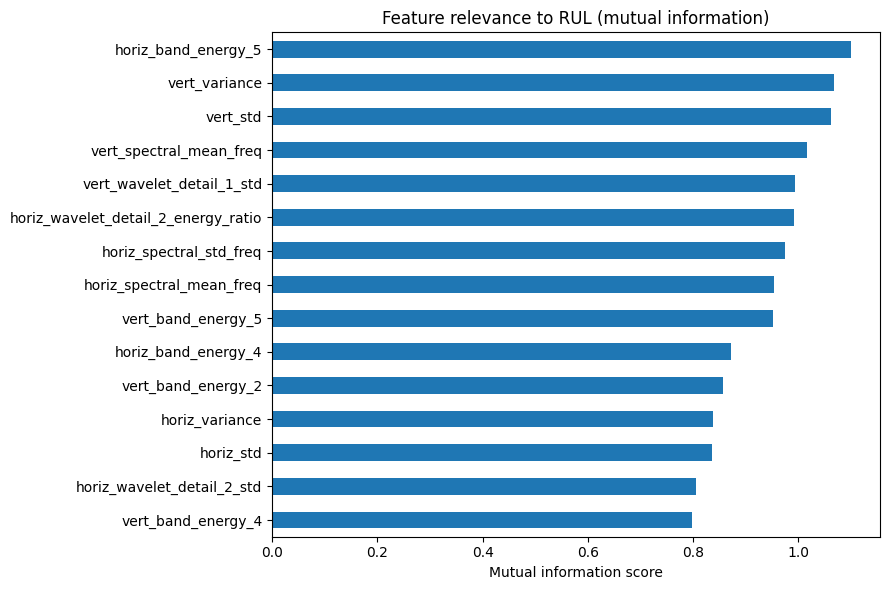


Final selected feature set (20 features):
 - horiz_band_energy_5
 - vert_variance
 - vert_std
 - vert_spectral_mean_freq
 - vert_wavelet_detail_1_std
 - horiz_wavelet_detail_2_energy_ratio
 - horiz_spectral_std_freq
 - horiz_spectral_mean_freq
 - vert_band_energy_5
 - horiz_band_energy_4
 - vert_band_energy_2
 - horiz_variance
 - horiz_std
 - horiz_wavelet_detail_2_std
 - vert_band_energy_4
 - horiz_band_energy_2
 - horiz_wavelet_approx_std
 - vert_wavelet_detail_2_energy_ratio
 - horiz_band_energy_3
 - vert_wavelet_detail_3_std


In [66]:
fig, ax = plt.subplots(figsize=(9, 6))
mi_ranking.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Feature relevance to RUL (mutual information)")
ax.set_xlabel("Mutual information score")
plt.tight_layout()
plt.show()

# Final selected feature set: top-N by MI (N chosen conservatively to balance
# model complexity against the LightGBM+SHAP pipeline's interpretability goal, O3)
N_FINAL_FEATURES = 20
final_feature_set = mi_ranking.head(N_FINAL_FEATURES).index.tolist()
print(f"\nFinal selected feature set ({len(final_feature_set)} features):")
for f in final_feature_set:
    print(" -", f)


In [67]:
def classify_feature(colname):
    """Classify a feature column into its domain based on the naming convention
    established in Sections 7-9 (time_domain_features / freq_domain_features / wavelet_features)."""
    if "wavelet" in colname:
        return "wavelet"
    elif "spectral" in colname or "band_energy" in colname:
        return "frequency"
    else:
        return "time"


def redundancy_filter(df_subset, threshold=0.95):
    """Same method as Section 10: drop features with pairwise correlation above threshold."""
    corr = df_subset.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = [col for col in upper.columns if any(upper[col] > threshold)]
    return df_subset.drop(columns=redundant), redundant


# X was built in Section 10 (all extracted features, NaN-filled)
domain_map = {c: classify_feature(c) for c in X.columns}

time_cols_raw      = [c for c, d in domain_map.items() if d == "time"]
time_freq_cols_raw = [c for c, d in domain_map.items() if d in ("time", "frequency")]
all_cols_raw       = list(X.columns)

X_time, dropped_time           = redundancy_filter(X[time_cols_raw])
X_time_freq, dropped_time_freq = redundancy_filter(X[time_freq_cols_raw])
X_all, dropped_all             = redundancy_filter(X[all_cols_raw])

print(f"Tier 1 (time only)        : {len(time_cols_raw)} raw -> {X_time.shape[1]} after redundancy filter "
      f"({len(dropped_time)} dropped)")
print(f"Tier 2 (time + frequency) : {len(time_freq_cols_raw)} raw -> {X_time_freq.shape[1]} after redundancy filter "
      f"({len(dropped_time_freq)} dropped)")
print(f"Tier 3 (all: +wavelet)    : {len(all_cols_raw)} raw -> {X_all.shape[1]} after redundancy filter "
      f"({len(dropped_all)} dropped)")


Tier 1 (time only)        : 24 raw -> 16 after redundancy filter (8 dropped)
Tier 2 (time + frequency) : 44 raw -> 30 after redundancy filter (14 dropped)
Tier 3 (all: +wavelet)    : 64 raw -> 45 after redundancy filter (19 dropped)


In [68]:
def classify_feature(colname):
    """Classify a feature column into its domain based on the naming convention
    established in Sections 7-9 (time_domain_features / freq_domain_features / wavelet_features)."""
    if "wavelet" in colname:
        return "wavelet"
    elif "spectral" in colname or "band_energy" in colname:
        return "frequency"
    else:
        return "time"


def redundancy_filter(df_subset, threshold=0.95):
    """Same method as Section 10: drop features with pairwise correlation above threshold."""
    corr = df_subset.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = [col for col in upper.columns if any(upper[col] > threshold)]
    return df_subset.drop(columns=redundant), redundant


# X was built in Section 10 (all extracted features, NaN-filled)
domain_map = {c: classify_feature(c) for c in X.columns}

time_cols_raw      = [c for c, d in domain_map.items() if d == "time"]
time_freq_cols_raw = [c for c, d in domain_map.items() if d in ("time", "frequency")]
all_cols_raw       = list(X.columns)

X_time, dropped_time           = redundancy_filter(X[time_cols_raw])
X_time_freq, dropped_time_freq = redundancy_filter(X[time_freq_cols_raw])
X_all, dropped_all             = redundancy_filter(X[all_cols_raw])

print(f"Tier 1 (time only)        : {len(time_cols_raw)} raw -> {X_time.shape[1]} after redundancy filter "
      f"({len(dropped_time)} dropped)")
print(f"Tier 2 (time + frequency) : {len(time_freq_cols_raw)} raw -> {X_time_freq.shape[1]} after redundancy filter "
      f"({len(dropped_time_freq)} dropped)")
print(f"Tier 3 (all: +wavelet)    : {len(all_cols_raw)} raw -> {X_all.shape[1]} after redundancy filter "
      f"({len(dropped_all)} dropped)")


Tier 1 (time only)        : 24 raw -> 16 after redundancy filter (8 dropped)
Tier 2 (time + frequency) : 44 raw -> 30 after redundancy filter (14 dropped)
Tier 3 (all: +wavelet)    : 64 raw -> 45 after redundancy filter (19 dropped)


In [69]:
# This cell is no longer needed as ROOT_DIR is set earlier and the dataset is already cloned.

In [70]:
import os

DRIVE_BASE = '/content/drive/MyDrive'

print("Contents of MyDrive:")
# List up to 30 items for a quick glance, handles large directories gracefully
# Check if DRIVE_BASE exists before listing to prevent FileNotFoundError
if os.path.exists(DRIVE_BASE) and os.path.isdir(DRIVE_BASE):
    for item in sorted(os.listdir(DRIVE_BASE))[:30]:
        print(" -", item)
else:
    print(f"Error: {DRIVE_BASE} does not exist or is not a directory. Drive might not be mounted correctly.")

print("\nSearching for 'Learning_set' folder under MyDrive...")
found_root_dir = None
for root, dirs, files in os.walk(DRIVE_BASE):
    if 'Learning_set' in dirs:
        found_root_dir = root
        print("FOUND at:", root)
        break

if found_root_dir:
    print("  Suggesting ROOT_DIR as:", found_root_dir)
    # It's important to update the ROOT_DIR in the next step or globally if needed
else:
    print("Not found. The dataset may not be uploaded/extracted yet,")
    print("or it's still inside a .zip file that needs extracting.")


Contents of MyDrive:
 - Colab Notebooks
 - FEMTO-ST
 - ieee-phm-2012-data-challenge-dataset

Searching for 'Learning_set' folder under MyDrive...
FOUND at: /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset
  Suggesting ROOT_DIR as: /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset


In [71]:
import pandas as pd
import os
import numpy as np
import glob # Added glob import for list_acc_files etc.
import time # Added missing import for time module
from scipy import stats # Added stats import for skewness/kurtosis
from scipy.fft import fft, fftfreq # Added fft imports for freq_domain_features
import pywt # Added pywt import for wavelet_features
from sklearn.feature_selection import mutual_info_regression

# --- Replicating global constants and helper functions from earlier cells ---
# From cell SDRLN0vlTWwm
RUNNING_IN_COLAB = True
# IMPORTANT: Verify this ROOT_DIR path matches where your dataset is cloned/extracted
# If your git clone created a folder like 'ieee-phm-2012-data-challenge-dataset.git', adjust below:
ROOT_DIR = '/content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset'  # <-- Adjust if needed!

# Check if ROOT_DIR exists
if not os.path.isdir(ROOT_DIR):
    print(f"CRITICAL ERROR: ROOT_DIR '{ROOT_DIR}' does not exist.\n" \
          "Please ensure Google Drive is mounted and the dataset is cloned/extracted to this path.")
    # Attempt to derive ROOT_DIR from a common git clone behavior if original didn't work
    if os.path.isdir(ROOT_DIR + '.git'):
        ROOT_DIR = ROOT_DIR + '.git'
        print(f"Corrected ROOT_DIR to: {ROOT_DIR}")
    else:
        # If still not found, set to a dummy path to prevent further errors
        print("Further attempts to find ROOT_DIR failed. Setting to dummy path.")
        ROOT_DIR = '/tmp/dummy_data_path'

LEARNING_SET   = os.path.join(ROOT_DIR, 'Learning_set')
FULL_TEST_SET  = os.path.join(ROOT_DIR, 'Full_Test_Set')
TEST_SET       = os.path.join(ROOT_DIR, 'Test_set')
FS_ACC = 25600
SAMPLES_PER_ACC_FILE = 2560

# Define OUTPUT_DIR here for consistent use across cells
OUTPUT_DIR = '/content/drive/MyDrive/FEMTO-ST/processed_features' if RUNNING_IN_COLAB else '/home/claude/processed_features'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# From cell XxYrAkn0Vph9
def list_bearings(set_path):
    """Return sorted bearing folder names within a dataset split, with directory check."""
    if not os.path.isdir(set_path):
        print(f"Warning: Directory not found: {set_path}. Returning empty list for bearings.")
        return []
    return sorted([d for d in os.listdir(set_path) if os.path.isdir(os.path.join(set_path, d))])
def list_acc_files(bearing_path):
    return sorted(glob.glob(os.path.join(bearing_path, "acc_*.csv")))
def list_temp_files(bearing_path):
    return sorted(glob.glob(os.path.join(bearing_path, "temp_*.csv")))
def _detect_delimiter(filepath):
    with open(filepath, "r") as f:
        first_line = f.readline()
    return ";" if ";" in first_line else ","
def read_acc_file(filepath):
    delim = _detect_delimiter(filepath)
    return pd.read_csv(filepath, header=None, sep=delim,
                        names=["hour", "min", "sec", "usec", "horiz", "vert"])

# From cell jQupfjOFd5hh
def bearing_condition(bearing_name):
    return bearing_name.split("_")[0].replace("Bearing", "Condition ")

# From cell eNyJ0SiOfqf8
def build_snapshot_index(set_name, set_path, full_test_lookup=None):
    """Build one row per accelerometer snapshot file, with RUL label and metadata.
    Includes check for set_path existence.
    """
    rows = []
    if not os.path.isdir(set_path):
        print(f"Warning: Dataset directory for '{set_name}' not found at '{set_path}'. Skipping snapshot indexing.")
        return pd.DataFrame(rows) # Return empty DataFrame if directory not found

    for bearing in list_bearings(set_path):
        bpath = os.path.join(set_path, bearing)
        acc_files = list_acc_files(bpath)
        temp_files = set(os.path.basename(f).replace("temp_", "").replace(".csv", "")
                          for f in list_temp_files(bpath))
        if set_name == "Test_set" and full_test_lookup is not None and bearing in full_test_lookup:
            total_life = full_test_lookup[bearing]
        else:
            total_life = len(acc_files)
        for i, f in enumerate(acc_files):
            idx_str = os.path.basename(f).replace("acc_", "").replace(".csv", "")
            rows.append({
                "set": set_name,
                "bearing": bearing,
                "condition": bearing_condition(bearing),
                "snapshot_idx": i + 1,
                "acc_filepath": f,
                "has_temperature": idx_str in temp_files,
                "total_life_snapshots": total_life,
                "RUL_snapshots": total_life - (i + 1),
            })
    return pd.DataFrame(rows)

# Add similar check for _full_test_lookup creation
if os.path.isdir(FULL_TEST_SET):
    _full_test_lookup = {
        b: len(list_acc_files(os.path.join(FULL_TEST_SET, b)))
        for b in list_bearings(FULL_TEST_SET)
    }
else:
    print(f"Warning: FULL_TEST_SET directory not found at {FULL_TEST_SET}. `_full_test_lookup` will be empty.")
    _full_test_lookup = {} # Empty lookup if directory is missing

print(f"DEBUG: Before building learning_index. LEARNING_SET: {LEARNING_SET}")
learning_index = build_snapshot_index("Learning_set", LEARNING_SET)
print(f"DEBUG: After building learning_index. learning_index shape: {learning_index.shape}. Is empty: {learning_index.empty}")

# Feature extraction functions from cells uBuMrOPlfzhf, 7jR2BwZ2f358, byU94sxTgEEe
def time_domain_features(sig, prefix=""):
    feats = {}
    rms = np.sqrt(np.mean(sig ** 2))
    peak = np.max(np.abs(sig))
    mean_abs = np.mean(np.abs(sig))
    feats[f"{prefix}mean"] = np.mean(sig)
    feats[f"{prefix}std"] = np.std(sig)
    feats[f"{prefix}rms"] = rms
    feats[f"{prefix}variance"] = np.var(sig)
    feats[f"{prefix}skewness"] = stats.skew(sig)
    feats[f"{prefix}kurtosis"] = stats.kurtosis(sig)
    feats[f"{prefix}peak"] = peak
    feats[f"{prefix}peak_to_peak"] = np.max(sig) - np.min(sig)
    feats[f"{prefix}crest_factor"] = peak / (rms + 1e-12)
    feats[f"{prefix}shape_factor"] = rms / (mean_abs + 1e-12)
    feats[f"{prefix}impulse_factor"] = peak / (mean_abs + 1e-12)
    feats[f"{prefix}clearance_factor"] = peak / (np.mean(np.sqrt(np.abs(sig))) ** 2 + 1e-12)
    return feats

def freq_domain_features(sig, fs=FS_ACC, prefix=""):
    n = len(sig)
    freqs = fftfreq(n, 1 / fs)[: n // 2]
    mags = np.abs(fft(sig))[: n // 2]
    mags_norm = mags / (np.sum(mags) + 1e-12)
    feats = {}
    mean_freq = np.sum(freqs * mags_norm)
    feats[f"{prefix}spectral_mean_freq"] = mean_freq
    feats[f"{prefix}spectral_rms_freq"] = np.sqrt(np.sum((freqs ** 2) * mags_norm))
    feats[f"{prefix}spectral_std_freq"] = np.sqrt(np.sum(((freqs - mean_freq) ** 2) * mags_norm))
    feats[f"{prefix}spectral_energy"] = np.sum(mags ** 2)
    feats[f"{prefix}spectral_entropy"] = -np.sum(mags_norm * np.log(mags_norm + 1e-12))
    n_bands = 5
    band_edges = np.linspace(0, fs / 2, n_bands + 1)
    for i in range(n_bands):
        mask = (freqs >= band_edges[i]) & (freqs < band_edges[i + 1])
        feats[f"{prefix}band_energy_{i+1}"] = np.sum(mags[mask] ** 2)
    return feats

def wavelet_features(sig, wavelet="db4", level=4, prefix=""):
    sig = np.array(sig, dtype=np.float64, copy=True)
    coeffs = pywt.wavedec(sig, wavelet, level=level)
    total_energy = sum(np.sum(c ** 2) for c in coeffs) + 1e-12
    feats = {}
    for i, c in enumerate(coeffs):
        name = "approx" if i == 0 else f"detail_{level - i + 1}"
        energy = np.sum(c ** 2)
        feats[f"{prefix}wavelet_{name}_energy_ratio"] = energy / total_energy
        feats[f"{prefix}wavelet_{name}_std"] = np.std(c)
    return feats

# From cell VPKNrS5IgJDJ - Ensure FAST_DEMO is False as per user's context
FAST_DEMO = False # Explicitly set to False for full data processing
DEMO_SNAPSHOTS_PER_BEARING = 100

def extract_features_row(acc_filepath):
    df = read_acc_file(acc_filepath)
    row = {}
    row.update(time_domain_features(df["horiz"].values, prefix="horiz_"))
    row.update(time_domain_features(df["vert"].values, prefix="vert_"))
    row.update(freq_domain_features(df["horiz"].values, prefix="horiz_"))
    row.update(freq_domain_features(df["vert"].values, prefix="vert_"))
    row.update(wavelet_features(df["horiz"].values, prefix="horiz_"))
    row.update(wavelet_features(df["vert"].values, prefix="vert_"))
    return row

def build_feature_dataset(snapshot_index_df, fast_demo=FAST_DEMO):
    if snapshot_index_df.empty:
        print("Warning: Input snapshot_index_df is empty. Cannot extract features.")
        return pd.DataFrame() # Return an empty DataFrame to avoid further errors

    all_rows = []
    bearings = snapshot_index_df["bearing"].unique()
    t_start = time.time() # Added for progress tracking
    for bearing in bearings:
        b_df = snapshot_index_df[snapshot_index_df["bearing"] == bearing].reset_index(drop=True)
        if fast_demo and len(b_df) > DEMO_SNAPSHOTS_PER_BEARING:
            sample_idx = np.linspace(0, len(b_df) - 1, DEMO_SNAPSHOTS_PER_BEARING).astype(int)
            b_df = b_df.iloc[sample_idx].reset_index(drop=True)
        for _, meta_row in b_df.iterrows():
            feats = extract_features_row(meta_row["acc_filepath"])
            feats.update({
                "set": meta_row["set"],
                "bearing": meta_row["bearing"],
                "condition": meta_row["condition"],
                "snapshot_idx": meta_row["snapshot_idx"],
                "has_temperature": meta_row["has_temperature"],
                "total_life_snapshots": meta_row["total_life_snapshots"],
                "RUL_snapshots": meta_row["RUL_snapshots"],
            })
            all_rows.append(feats)
        print(f"  {bearing}: {len(b_df)} snapshots processed ({time.time()-t_start:.1f}s elapsed)") # Progress print
    return pd.DataFrame(all_rows)

print("Building feature dataset for Learning_set" \
      + (" (FAST_DEMO subsample)" if FAST_DEMO else " (full)") + " ...") # Initial print
# Define learning_features
learning_features = build_feature_dataset(learning_index, fast_demo=FAST_DEMO)
print(f"\nDone. Shape: {learning_features.shape}") # Final print

# --- Original code from w4VPPGM-iwy5 and 8I__q3miEsJW continues below ---
# Add a check for empty learning_features before proceeding
if learning_features.empty:
    print("Fatal Error: `learning_features` DataFrame is empty. Cannot proceed with feature selection.")
    print("Please ensure your `ROOT_DIR` is correctly set and accessible, and that data directories contain files.")
else:
    feature_cols = [c for c in learning_features.columns
                    if c not in ["set", "bearing", "condition", "snapshot_idx",
                                 "has_temperature", "total_life_snapshots", "RUL_snapshots"]]
    X = learning_features[feature_cols].fillna(0)
    y = learning_features["RUL_snapshots"]

    # --- Step 1: redundancy filter (correlation > 0.95) ---
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    redundant = [col for col in upper.columns if any(upper[col] > 0.95)]
    X_reduced = X.drop(columns=redundant)
    # --- End of replication from w4VPPGM-iwy5 ---

    # --- Step 2: relevance ranking via mutual information with RUL ---
    mi_scores = mutual_info_regression(X_reduced, y, random_state=42)
    mi_ranking = pd.Series(mi_scores, index=X_reduced.columns).sort_values(ascending=False)

    # Final selected feature set: top-N by MI
    N_FINAL_FEATURES = 20
    final_feature_set = mi_ranking.head(N_FINAL_FEATURES).index.tolist()

    # Full feature ranking (all features considered in Section 10, ranked by MI relevance to RUL)
    feature_ranking_df = mi_ranking.reset_index()
    feature_ranking_df.columns = ["feature", "mutual_information_score"]
    feature_ranking_df["rank"] = feature_ranking_df.index + 1
    feature_ranking_df["selected"] = feature_ranking_df["feature"].isin(final_feature_set)

    ranking_path = os.path.join(OUTPUT_DIR, "feature_ranking.csv")

    feature_ranking_df.to_csv(ranking_path, index=False)
    print(f"Saved feature ranking -> {ranking_path}  {feature_ranking_df.shape}")
    display(feature_ranking_df.head(10))

DEBUG: Before building learning_index. LEARNING_SET: /content/drive/MyDrive/ieee-phm-2012-data-challenge-dataset/Learning_set
DEBUG: After building learning_index. learning_index shape: (7534, 8). Is empty: False
Building feature dataset for Learning_set (full) ...
  Bearing1_1: 2803 snapshots processed (45.1s elapsed)
  Bearing1_2: 871 snapshots processed (57.6s elapsed)
  Bearing2_1: 911 snapshots processed (70.8s elapsed)
  Bearing2_2: 797 snapshots processed (82.4s elapsed)
  Bearing3_1: 515 snapshots processed (89.5s elapsed)
  Bearing3_2: 1637 snapshots processed (112.9s elapsed)

Done. Shape: (7534, 71)
Saved feature ranking -> /content/drive/MyDrive/FEMTO-ST/processed_features/feature_ranking.csv  (45, 4)


,feature,mutual_information_score,rank,selected
0,horiz_band_energy_5,1.100410,1,True
1,vert_variance,1.068274,2,True
2,vert_std,1.062416,3,True
3,vert_spectral_mean_freq,1.016635,4,True
4,vert_wavelet_detail_1_std,0.992917,5,True
5,horiz_wavelet_detail_2_energy_ratio,0.991513,6,True
6,horiz_spectral_std_freq,0.975183,7,True
7,horiz_spectral_mean_freq,0.953084,8,True
8,vert_band_energy_5,0.951773,9,True
9,horiz_band_energy_4,0.872334,10,True


In [72]:
import os

if os.path.exists('/content/drive') and os.path.isdir('/content/drive'):
    print("/content/drive exists and is a directory.")
else:
    print("/content/drive does NOT exist or is not a directory. Please check your Google Drive mount.")

/content/drive exists and is a directory.


In [73]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [74]:
# Final selected feature list (the exact features used by the primary model), with their MI scores
selected_features_df = feature_ranking_df[feature_ranking_df["selected"]].reset_index(drop=True)

selected_path = os.path.join(OUTPUT_DIR, "selected_features.csv")
selected_features_df.to_csv(selected_path, index=False)
print(f"Saved selected feature list -> {selected_path}  {selected_features_df.shape}")
selected_features_df


Saved selected feature list -> /content/drive/MyDrive/FEMTO-ST/processed_features/selected_features.csv  (20, 4)


,feature,mutual_information_score,rank,selected
0,horiz_band_energy_5,1.100410,1,True
1,vert_variance,1.068274,2,True
2,vert_std,1.062416,3,True
3,vert_spectral_mean_freq,1.016635,4,True
4,vert_wavelet_detail_1_std,0.992917,5,True
5,horiz_wavelet_detail_2_energy_ratio,0.991513,6,True
6,horiz_spectral_std_freq,0.975183,7,True
7,horiz_spectral_mean_freq,0.953084,8,True
8,vert_band_energy_5,0.951773,9,True
9,horiz_band_energy_4,0.872334,10,True


In [75]:
OUTPUT_DIR = '/content/drive/MyDrive/FEMTO-ST/processed_features' if RUNNING_IN_COLAB else '/home/claude/processed_features'
os.makedirs(OUTPUT_DIR, exist_ok=True)

full_path = os.path.join(OUTPUT_DIR, "chapter4_features_full.csv")
selected_bonus_path = os.path.join(OUTPUT_DIR, "chapter4_features_selected.csv")

learning_features.to_csv(full_path, index=False)

meta_cols = ["set", "bearing", "condition", "snapshot_idx", "has_temperature",
             "total_life_snapshots", "RUL_snapshots"]
learning_features[meta_cols + final_feature_set].to_csv(selected_bonus_path, index=False)

print(f"Saved full feature table    -> {full_path}  {learning_features.shape}")
print(f"Saved selected feature table -> {selected_bonus_path}  "
      f"{learning_features[meta_cols + final_feature_set].shape}")


# --- Re-defining X_time, X_time_frequency, X_all for robustness (from cell 38d1d97d) ---
def classify_feature(colname):
    """Classify a feature column into its domain based on the naming convention."""
    if "wavelet" in colname:
        return "wavelet"
    elif "spectral" in colname or "band_energy" in colname:
        return "frequency"
    else:
        return "time"

def redundancy_filter(df_subset, threshold=0.95):
    """Drop features with pairwise correlation above threshold."""
    corr = df_subset.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = [col for col in upper.columns if any(upper[col] > threshold)]
    return df_subset.drop(columns=redundant), redundant

domain_map = {c: classify_feature(c) for c in X.columns}

time_cols_raw      = [c for c, d in domain_map.items() if d == "time"]
time_freq_cols_raw = [c for c, d in domain_map.items() if d in ("time", "frequency")]
all_cols_raw       = list(X.columns)

X_time, dropped_time           = redundancy_filter(X[time_cols_raw])
X_time_freq, dropped_time_freq = redundancy_filter(X[time_freq_cols_raw])
X_all, dropped_all             = redundancy_filter(X[all_cols_raw])
# --- End of re-definition block ---


# --- Three-tier feature datasets (Section 10b) for Chapter 5's feature-set ablation ---
meta_cols_tiered = ["set", "bearing", "condition", "snapshot_idx", "has_temperature",
                     "total_life_snapshots", "RUL_snapshots"]

time_path      = os.path.join(OUTPUT_DIR, "features_time.csv")
time_frequency_path = os.path.join(OUTPUT_DIR, "features_time_frequency.csv")
all_path       = os.path.join(OUTPUT_DIR, "features_all.csv")

learning_features[meta_cols_tiered].join(X_time).to_csv(time_path, index=False)
learning_features[meta_cols_tiered].join(X_time_freq).to_csv(time_frequency_path, index=False)
learning_features[meta_cols_tiered].join(X_all).to_csv(all_path, index=False)

print(f"Saved Tier 1 (time only)        -> {time_path}  "
      f"{learning_features[meta_cols_tiered].join(X_time).shape}")
print(f"Saved Tier 2 (time+frequency)   -> {time_frequency_path}  "
      f"{learning_features[meta_cols_tiered].join(X_time_freq).shape}")
print(f"Saved Tier 3 (all: +wavelet)    -> {all_path}  "
      f"{learning_features[meta_cols_tiered].join(X_all).shape}")
print()
print("Chapter 5 should train/compare the same model (e.g. LightGBM) on all three tiers")
print("using identical train/test splits and hyperparameters, and report RMSE/MAE/R2 per tier")
print("-> this directly answers RQ1 and produces a genuine ablation table for the paper.")

Saved full feature table    -> /content/drive/MyDrive/FEMTO-ST/processed_features/chapter4_features_full.csv  (7534, 71)
Saved selected feature table -> /content/drive/MyDrive/FEMTO-ST/processed_features/chapter4_features_selected.csv  (7534, 27)
Saved Tier 1 (time only)        -> /content/drive/MyDrive/FEMTO-ST/processed_features/features_time.csv  (7534, 23)
Saved Tier 2 (time+frequency)   -> /content/drive/MyDrive/FEMTO-ST/processed_features/features_time_frequency.csv  (7534, 37)
Saved Tier 3 (all: +wavelet)    -> /content/drive/MyDrive/FEMTO-ST/processed_features/features_all.csv  (7534, 52)

Chapter 5 should train/compare the same model (e.g. LightGBM) on all three tiers
using identical train/test splits and hyperparameters, and report RMSE/MAE/R2 per tier
-> this directly answers RQ1 and produces a genuine ablation table for the paper.


In [76]:
print("=" * 55)
print("CHAPTER 4 — FEATURE ENGINEERING: SUMMARY")
print("=" * 55)
print(f"Total extracted features (time + frequency + wavelet, both axes): {X.shape[1]}")
print(f"After correlation filtering (>0.95, full combined set):           {X_all.shape[1]}")
print(f"Final selected features (top-{N_FINAL_FEATURES} by mutual information):          {len(final_feature_set)}")
print()
print("Feature set sizes by tier (each independently redundancy-filtered):")
print(f"  Tier 1 - Time only          : {X_time.shape[1]} features")
print(f"  Tier 2 - Time + Frequency   : {X_time_freq.shape[1]} features")
print(f"  Tier 3 - All (+ Wavelet)    : {X_all.shape[1]} features")
print()
print("Output files:")
_expected_files = {
    "features_time.csv": time_path,
    "features_time_frequency.csv": time_frequency_path,
    "features_all.csv": all_path,
    "feature_ranking.csv": ranking_path,
    "selected_features.csv": selected_path,
    "chapter4_features_full.csv (bonus)": full_path,
    "chapter4_features_selected.csv (bonus)": selected_bonus_path if 'selected_bonus_path' in dir() else None,
}
for label, path in _expected_files.items():
    if path is not None and os.path.exists(path):
        print(f"  ✓ {label}")
    else:
        print(f"  ✗ {label}  <-- MISSING, check earlier cells")
print("=" * 55)

CHAPTER 4 — FEATURE ENGINEERING: SUMMARY
Total extracted features (time + frequency + wavelet, both axes): 64
After correlation filtering (>0.95, full combined set):           45
Final selected features (top-20 by mutual information):          20

Feature set sizes by tier (each independently redundancy-filtered):
  Tier 1 - Time only          : 16 features
  Tier 2 - Time + Frequency   : 30 features
  Tier 3 - All (+ Wavelet)    : 45 features

Output files:
  ✓ features_time.csv
  ✓ features_time_frequency.csv
  ✓ features_all.csv
  ✓ feature_ranking.csv
  ✓ selected_features.csv
  ✓ chapter4_features_full.csv (bonus)
  ✓ chapter4_features_selected.csv (bonus)
